In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import bombcell as bc
import spikeinterface.full as si
import zarr
from pprint import pprint
from spikeshpc import open_stream, load_states, show_state_epochs, show_state_editor, derive_shutter_times, load_concatenated
from spikeshpc import optitrack as optitrack

✅ ipywidgets available - interactive GUI ready


In [4]:
# Set global arguments for parallel processing
global_job_kwargs = dict(n_jobs=8, chunk_duration="1s", progress_bar=True)
si.set_global_job_kwargs(**global_job_kwargs)

# Set directories
session = "session10_pupil"
project_dir = Path(r"C:\Working\session10_pupil")
phys_path = Path(r"C:\Working\session10_pupil\raw")
ks_path = project_dir / "kilosort4"
spikes_path = project_dir / "analyzer.zarr"
states_path = project_dir / "states"
shutter_close_path = states_path / "session9_shutter_close_times.npy"

# OptiTrack take (CSV export) synced to the recording above
optitrack_csv_path = project_dir / "session10_optitrack.csv"

# Open Ephys: stream to read (only used if is_open_ephys is True)
oe_stream_name = "OneBox-109.ProbeA"
oe_event_name = "OneBox-109.OneBox-ADC"
oe_adc_id = "ADC0"

In [5]:
# 1. Load recording
# open_stream rather than si.read_openephys: loads the acquisition
# system's own timestamps and checks them instead of inferring times from
# declared sampling rate. OneBox ADC declares 30300.5 Hz and really runs
# at ~30303 -- 83 ppm: ~5 s of error by the end of 12h session
recording, info = load_concatenated(project_dir) # Loads CAR subtacted bin file
events_raw = open_stream(phys_path, "openephysbinary", oe_event_name)

In [6]:
# 2. Load KS4 output
sorting = si.read_kilosort(ks_path)
channel_map = np.load(ks_path / "channel_map.npy")
recording_for_analysis = recording.select_channels(
    channel_ids=recording.channel_ids[channel_map]
)
ks_labels = sorting._properties["KSLabel"]

In [7]:
# 3. Load the sorting analyzer if it was already saved to spikes_path
zarr_root = zarr.open(str(spikes_path), mode="r+")
if (
        "extensions" in zarr_root.keys()
        and "spiketrain_metrics" in zarr_root["extensions"].keys()
):
    del zarr_root["extensions"]["spiketrain_metrics"]
zarr.consolidate_metadata(zarr_root.store)

analyzer = si.load_sorting_analyzer(spikes_path)
print(f"Loaded existing sorting analyzer from {spikes_path}")

Loaded existing sorting analyzer from C:\Working\session10_pupil\analyzer.zarr


In [1]:
# 4 Load sleep scoring
# scoring = load_states(states_path)  # or states_path, session="session6a"

In [ ]:
# 5 Check sleep scoring manually
# %matplotlib qt
# widget = show_state_editor(scoring, log_signals=[])  # ← → to step through epochs

In [ ]:
si.plot_sorting_summary(sorting_analyzer=analyzer, backend="spikeinterface_gui")

In [45]:
bc_settings = pd.read_parquet(r"C:\Working\_bc_parameters._bc_qMetrics.parquet")
bc_settings = bc_settings.sort_index(axis=1)

In [11]:
param = bc.get_default_parameters(
    ks_path,
    raw_file=r"C:\Working\session10_pupil\preprocessed.bin",
    meta_file=r"C:\Working\session10_pupil\raw\experiment1\recording1\structure.oebin",
    kilosort_version=4
)
pprint(param)

{'computeDistanceMetrics': False,
 'computeDrift': False,
 'computeSpatialDecay': True,
 'computeTimeChunks': False,
 'confidence_threshold': 0.9,
 'contamination_values': None,
 'decompress_data': False,
 'deltaTimeChunk': 360,
 'detrendForUnitMatch': False,
 'detrendWaveform': True,
 'driftBinSize': 60,
 'duplicateSpikeWindow_s': 3.4e-05,
 'ephysKilosortPath': 'C:\\Working\\session10_pupil\\kilosort4',
 'ephys_meta_file': 'C:\\Working\\session10_pupil\\raw\\experiment1\\recording1\\structure.oebin',
 'ephys_sample_rate': 30000,
 'extractRaw': True,
 'gain_to_uV': 0.1949999928474426,
 'hillOrLlobetMethod': True,
 'isoDmin': 20,
 'lratioMax': 0.3,
 'maxDrift': 100,
 'maxMainPeakToTroughRatio_nonSomatic': 0.8,
 'maxNPeaks': 2,
 'maxNTroughs': 1,
 'maxPeak1ToPeak2Ratio_nonSomatic': 3,
 'maxPercSpikesMissing': 20,
 'maxRPVviolations': 0.1,
 'maxScndPeakToTroughRatio_noise': 0.8,
 'maxSpatialDecaySlopeExp': 0.1,
 'maxWvBaselineFraction': 0.3,
 'maxWvDuration': 1150,
 'minAmplitude': 40,
 '

In [9]:
# Apply Carandini lab customizations
# param["computeTimeChunks"] = True
# param["decompress_data"] = True
# param["lratioMax"] = 0.1
# param["maxDrift"] = 500
# param["maxWvDuration"] = 800
# param["minAmplitude"] = 20
# param["minPresenceRatio"] = 0.2
# param["minSNR"] = 0.9
# param["minSpatialDecaySlope"] = -0.003
# param["nRawSpikesToExtract"] = 1000
# param["reextractRaw"] = True
# param["tauR_values"] = np.arange(0.0005, 0.01 + 0.0001, 0.0005)
# param["waveformBaselineNoiseWindow"] = 20
# param["waveform_baseline_window_start"] = 20
# param["waveform_baseline_window_stop"] = 30

🚀 Starting BombCell quality metrics pipeline...
📁 Processing data from: C:\Working\session10_pupil\kilosort4
Results will be saved to: C:\Working\session10_pupil\bombcell

Loading ephys data...
Loaded ephys data: 270 units, 2,456,965 spikes

🔍 Extracting raw waveforms...
Loading file C:\Working\session10_pupil\bombcell\templates._bc_rawWaveforms.npy... Done!
No splits/merges detected

⚙️ Computing quality metrics for 270 units...
   (Progress bar will appear below)


Computing bombcell quality metrics:   0%|          | 0/270 units


Saving GUI visualization data...
GUI visualization data saved to: C:\Working\session10_pupil\bombcell\for_GUI\gui_data.pkl
   Generated spatial decay fits: 268/270 units
   Generated amplitude fits: 268/270 units

🏷️ Classifying units (good/MUA/noise/non-soma)...

Generating summary plots...


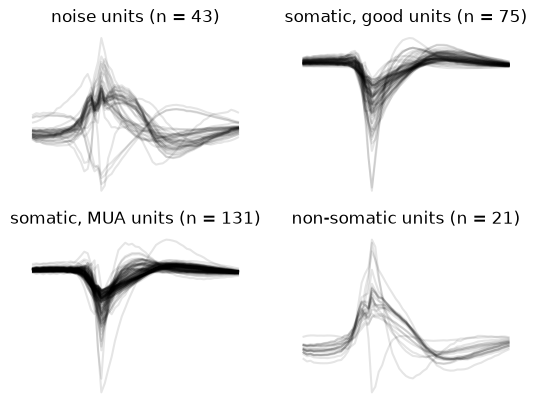

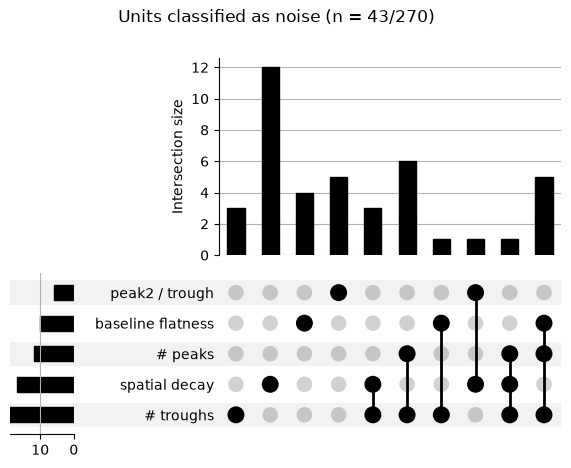

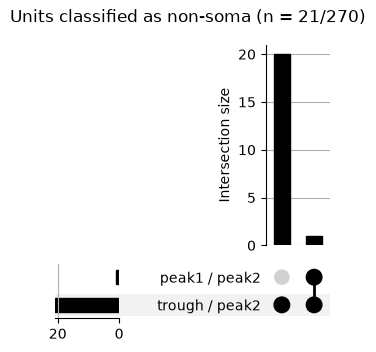

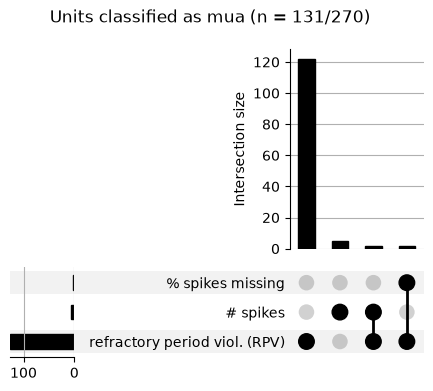

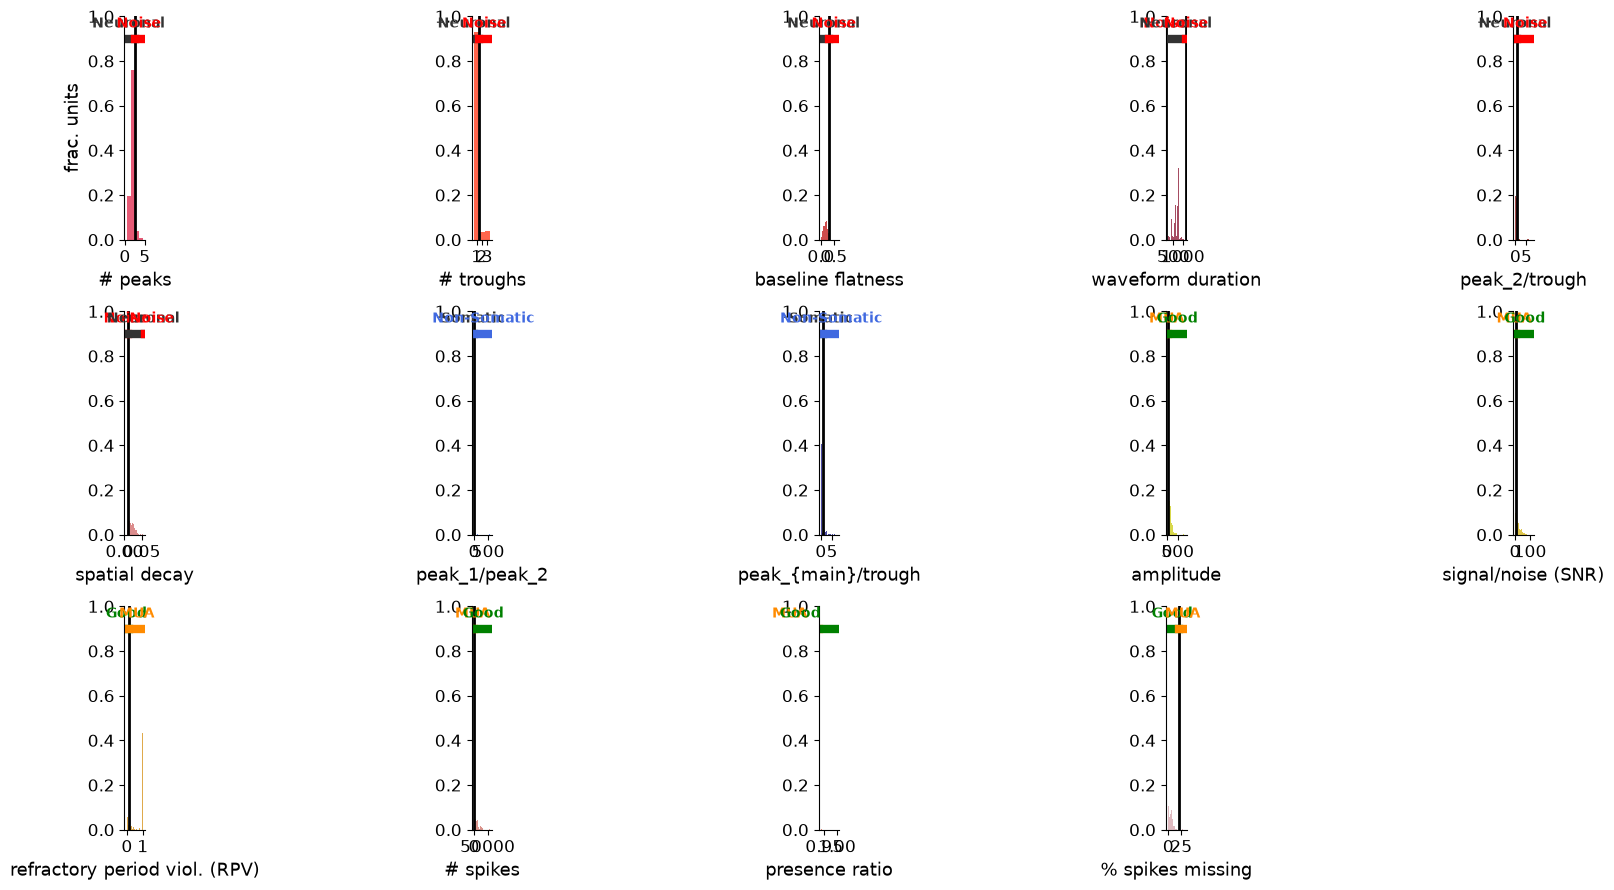


Saving results...
📁 Saving TSV files to Kilosort directory: C:\Working\session10_pupil\kilosort4
All expected metrics were successfully saved.


In [12]:
quality_metrics, param, unit_type, unit_type_string = bc.run_bombcell(ks_path, project_dir / "bombcell", param)

In [13]:
# quality metric values
quality_metrics_table = pd.DataFrame(quality_metrics)
quality_metrics_table.insert(0, 'Bombcell_unit_type', unit_type_string)
quality_metrics_table

,Bombcell_unit_type,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,scndPeakToTroughRatio,mainPeakToTroughRatio,...,maxDriftEstimate,cumDriftEstimate,rawAmplitude,signalToNoiseRatio,isolationDistance,Lratio,silhouetteScore,useTheseTimesStart,useTheseTimesStop,maxChannels
0,MUA,0,330.0,1.0,1.0,533.333333,0.010253,0.099844,0.331547,0.331547,...,NaN,NaN,91.128119,18.390125,NaN,NaN,NaN,0.000067,976.703367,3
1,MUA,1,1018.0,2.0,1.0,633.333333,0.015907,0.165608,0.287540,0.287540,...,NaN,NaN,91.156423,22.680719,NaN,NaN,NaN,0.000067,976.703367,6
2,MUA,2,567.0,2.0,1.0,633.333333,0.010749,0.186447,0.335424,0.335424,...,NaN,NaN,93.408257,13.060293,NaN,NaN,NaN,0.000067,976.703367,9
3,MUA,3,603.0,2.0,1.0,733.333333,0.014010,0.179793,0.310643,0.310643,...,NaN,NaN,87.132073,48.120309,NaN,NaN,NaN,0.000067,976.703367,12
4,MUA,4,1285.0,2.0,1.0,533.333333,0.010096,0.164113,0.380126,0.380126,...,NaN,NaN,85.875853,13.136601,NaN,NaN,NaN,0.000067,976.703367,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,NOISE,265,383.0,1.0,1.0,633.333333,0.007322,0.207459,0.085904,2.487648,...,NaN,NaN,68.527101,5.947657,NaN,NaN,NaN,0.000067,976.703367,358
266,NON-SOMA,266,265.0,1.0,1.0,500.000000,0.010759,0.147174,0.077440,2.112102,...,NaN,NaN,67.975370,5.167061,NaN,NaN,NaN,0.000067,976.703367,363
267,NOISE,267,187.0,1.0,1.0,633.333333,0.008450,0.208308,0.081139,2.868739,...,NaN,NaN,93.348937,5.706559,NaN,NaN,NaN,0.000067,976.703367,369
268,NOISE,268,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,373


In [14]:
# boolean table, if quality metrics pass threshold given parameters
boolean_quality_metrics_table = bc.make_qm_table(
    quality_metrics, param, unit_type_string
)
boolean_quality_metrics_table

,unit_type,Original ID,# peaks,# troughs,waveform duration,baseline flatness,peak2 / trough,spatial decay,% spikes missing,presence ratio,# spikes,fraction RPVs,amplitude,SNR,trough / peak2,peak1 / peak2
0,MUA,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,MUA,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,MUA,2,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,MUA,3,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,MUA,4,False,False,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,NOISE,265,False,False,False,False,False,True,False,False,False,False,False,False,False,False
266,NON-SOMA,266,False,False,False,False,False,False,False,False,False,False,False,False,True,False
267,NOISE,267,False,False,False,False,False,True,False,False,False,False,False,False,False,False
268,NOISE,268,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [20]:
# Launch minimal GUI.
# Ideally, take a look at your units for a few datasets so you can get an idea of which
# parameters will work best for your purposes.
%matplotlib inline
gui = bc.unit_quality_gui(
    ks_dir=ks_path,
    quality_metrics=quality_metrics,
    unit_types=unit_type,
    param=param,
    save_path=project_dir / "bombcell",
)

Loaded GUI data from: C:\Working\session10_pupil\bombcell\for_GUI\gui_data.pkl
🚀 Auto-loaded GUI data from: C:\Working\session10_pupil\bombcell\for_GUI\gui_data.pkl
GUI data loaded successfully!
   Data types available: ['peak_locations', 'trough_locations', 'peak_loc_for_duration', 'trough_loc_for_duration', 'peak_trough_labels', 'duration_lines', 'spatial_decay_fits', 'amplitude_fits', 'channel_arrangements', 'waveform_scaling', 'acg_data', 'per_bin_metrics']
   Peak/trough detection: 268 units
   Spatial decay fits: 268 units
   Amplitude fits: 268 units
   Note: Filtering out 18 units with < 300 spikes (have NaN metrics)
Total units: 252
📝 Initialized manual classification system (no previous classifications found)
🚀 Auto-advance enabled: will automatically go to next unit after classification


In [ ]:
# 7. Load shutter close times from the HPC analysis
# shutter_close_times = np.load(shutter_close_path)
config = {
    "ap_stream_name": oe_stream_name,
    "adc_stream_name": oe_event_name,
    "adc_channel": oe_adc_id,
    "save_sanity_plot": True,
}
cached = derive_shutter_times(
    phys_path=phys_path,
    output_dir=states_path,
    session=session,
    config=config,
    phys_type="openephysbinary",
    optitrack_csv=optitrack_csv_path,
    force=True,
)
shutter_close_times = np.load(cached)

print(f"Detected {len(shutter_close_times)} shutter-closure events")
if len(shutter_close_times) > 1:
    isis = np.diff(shutter_close_times)
print(
    f"Inter-frame interval: {isis.mean() * 1000:.3f} +/- {isis.std() * 1000:.3f} ms "
    f"({1 / isis.mean():.2f} Hz), range [{isis.min() * 1000:.3f}, {isis.max() * 1000:.3f}] ms"
)

# Cross-check against the OptiTrack CSV export (ground-truth frame count)
sync_stats = optitrack.cross_check_with_optitrack_csv(
    shutter_close_times, optitrack_csv_path
)
pprint(sync_stats)

fig = optitrack.plot_shutter_close_sanity_check(events_raw, shutter_close_times, channel_id=oe_adc_id)